In [1]:
# ================================================
# Chest X-ray Pneumonia Classification
# Notebook 3: Vision Transformer (ViT) Fine-tuning
# ================================================

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import timm  # library that has pretrained ViT models

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("Timm version:", timm.__version__)

Using device: cpu
Timm version: 1.0.27


In [3]:
# ================================================
# Paths and DataLoaders
# ================================================

DATA_DIR  = r"C:\Users\maria\Documents\chest_xray_project\data\chest_xray"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR   = os.path.join(DATA_DIR, "val")
TEST_DIR  = os.path.join(DATA_DIR, "test")

# ViT needs 224x224 images - same as ResNet18
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Datasets
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
val_dataset   = datasets.ImageFolder(VAL_DIR,   transform=val_test_transforms)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=val_test_transforms)

# DataLoaders - keep batch size small for CPU
BATCH_SIZE   = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
print("Data ready!")

Train: 5216 | Val: 16 | Test: 624
Data ready!


In [4]:
# ================================================
# Approach 1: FROZEN ViT
# We freeze all layers and only train the classifier head
# This is fast but less powerful
# ================================================

model_frozen = timm.create_model(
    "vit_base_patch16_224",  # ViT Base model with 16x16 patches
    pretrained=True,          # use ImageNet pretrained weights
    num_classes=2             # our 2 classes: Normal vs Pneumonia
)

# Freeze ALL layers
for param in model_frozen.parameters():
    param.requires_grad = False

# Unfreeze only the final classification head
for param in model_frozen.head.parameters():
    param.requires_grad = True

model_frozen = model_frozen.to(device)

# Count parameters
trainable = sum(p.numel() for p in model_frozen.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_frozen.parameters())
print(f"FROZEN ViT")
print(f"Trainable parameters: {trainable:,}")
print(f"Total parameters:     {total:,}")

FROZEN ViT
Trainable parameters: 1,538
Total parameters:     85,800,194


In [5]:
# ================================================
# Train Frozen ViT
# ================================================

NUM_EPOCHS = 5
criterion  = nn.CrossEntropyLoss()
optimizer  = optim.Adam(
    filter(lambda p: p.requires_grad, model_frozen.parameters()),
    lr=0.001
)

train_losses_frozen = []
val_losses_frozen   = []
train_accs_frozen   = []
val_accs_frozen     = []

print("Training Frozen ViT...")
print("-" * 70)

for epoch in range(NUM_EPOCHS):

    # Training phase
    model_frozen.train()
    running_loss = 0.0
    correct      = 0
    total        = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model_frozen(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted  = torch.max(outputs, 1)
        total        += labels.size(0)
        correct      += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc  = 100 * correct / total
    train_losses_frozen.append(train_loss)
    train_accs_frozen.append(train_acc)

    # Validation phase
    model_frozen.eval()
    val_loss = 0.0
    correct  = 0
    total    = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images  = images.to(device)
            labels  = labels.to(device)
            outputs = model_frozen(images)
            loss    = criterion(outputs, labels)

            val_loss    += loss.item()
            _, predicted = torch.max(outputs, 1)
            total       += labels.size(0)
            correct     += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc  = 100 * correct / total
    val_losses_frozen.append(val_loss)
    val_accs_frozen.append(val_acc)

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

print("\nFrozen ViT Training Complete!")

Training Frozen ViT...
----------------------------------------------------------------------
Epoch [1/5] Train Loss: 0.1790 | Train Acc: 92.79% | Val Loss: 0.3101 | Val Acc: 81.25%
Epoch [2/5] Train Loss: 0.1185 | Train Acc: 95.36% | Val Loss: 0.4314 | Val Acc: 81.25%
Epoch [3/5] Train Loss: 0.1076 | Train Acc: 96.09% | Val Loss: 0.4492 | Val Acc: 75.00%
Epoch [4/5] Train Loss: 0.0899 | Train Acc: 96.66% | Val Loss: 0.2763 | Val Acc: 87.50%
Epoch [5/5] Train Loss: 0.0928 | Train Acc: 96.53% | Val Loss: 0.2158 | Val Acc: 93.75%

Frozen ViT Training Complete!


FROZEN ViT - Test Set Results
              precision    recall  f1-score   support

      NORMAL       0.96      0.65      0.77       234
   PNEUMONIA       0.82      0.98      0.89       390

    accuracy                           0.86       624
   macro avg       0.89      0.81      0.83       624
weighted avg       0.87      0.86      0.85       624



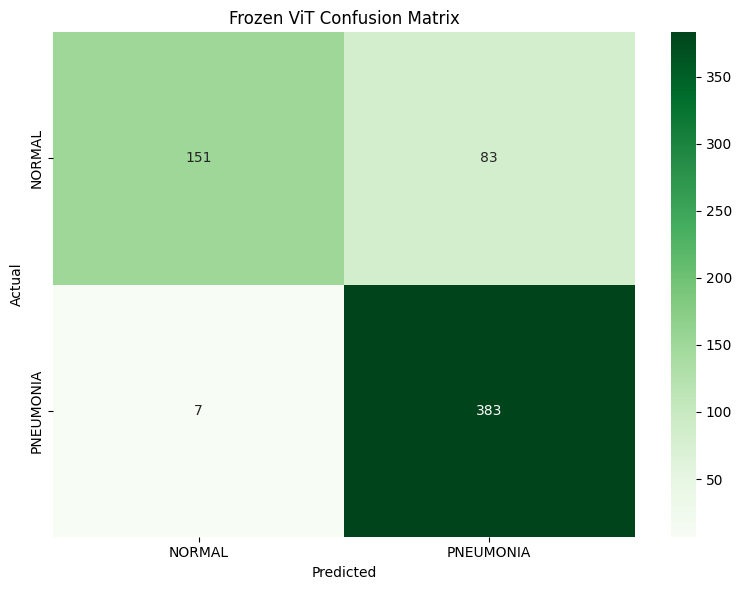

In [6]:
# ================================================
# Evaluate Frozen ViT on Test Set
# ================================================

model_frozen.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(device)
        outputs = model_frozen(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print("=" * 50)
print("FROZEN ViT - Test Set Results")
print("=" * 50)
print(classification_report(all_labels, all_preds,
      target_names=["NORMAL", "PNEUMONIA"]))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["NORMAL", "PNEUMONIA"],
            yticklabels=["NORMAL", "PNEUMONIA"])
plt.title("Frozen ViT Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

In [7]:
# ================================================
# Approach 2: FULL Fine-tuning ViT
# We unfreeze ALL layers and train everything
# More powerful but slower
# ================================================

model_full = timm.create_model(
    "vit_base_patch16_224",
    pretrained=True,
    num_classes=2
)

# Unfreeze ALL layers - train everything
for param in model_full.parameters():
    param.requires_grad = True

model_full = model_full.to(device)

trainable = sum(p.numel() for p in model_full.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_full.parameters())
print(f"FULL Fine-tuning ViT")
print(f"Trainable parameters: {trainable:,}")
print(f"Total parameters:     {total:,}")
print("\n⚠️  Warning: This will be slow on CPU!")
print("We use only 3 epochs and small learning rate")

FULL Fine-tuning ViT
Trainable parameters: 85,800,194
Total parameters:     85,800,194

⚠️  Warning: This will be slow on CPU!
We use only 3 epochs and small learning rate


In [8]:
# ================================================
# Train Full ViT
# Use smaller learning rate for full fine-tuning
# ================================================

NUM_EPOCHS = 3  # fewer epochs since it's slower
criterion  = nn.CrossEntropyLoss()
optimizer  = optim.Adam(model_full.parameters(), lr=0.00001)  # very small lr

train_losses_full = []
val_losses_full   = []
train_accs_full   = []
val_accs_full     = []

print("Training Full ViT (this will take a while on CPU)...")
print("-" * 70)

for epoch in range(NUM_EPOCHS):

    # Training phase
    model_full.train()
    running_loss = 0.0
    correct      = 0
    total        = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model_full(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted  = torch.max(outputs, 1)
        total        += labels.size(0)
        correct      += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc  = 100 * correct / total
    train_losses_full.append(train_loss)
    train_accs_full.append(train_acc)

    # Validation phase
    model_full.eval()
    val_loss = 0.0
    correct  = 0
    total    = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images  = images.to(device)
            labels  = labels.to(device)
            outputs = model_full(images)
            loss    = criterion(outputs, labels)

            val_loss    += loss.item()
            _, predicted = torch.max(outputs, 1)
            total       += labels.size(0)
            correct     += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc  = 100 * correct / total
    val_losses_full.append(val_loss)
    val_accs_full.append(val_acc)

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

print("\nFull ViT Training Complete!")

Training Full ViT (this will take a while on CPU)...
----------------------------------------------------------------------
Epoch [1/3] Train Loss: 0.1284 | Train Acc: 95.21% | Val Loss: 0.1229 | Val Acc: 100.00%
Epoch [2/3] Train Loss: 0.0592 | Train Acc: 97.74% | Val Loss: 0.0354 | Val Acc: 100.00%
Epoch [3/3] Train Loss: 0.0458 | Train Acc: 98.39% | Val Loss: 0.1372 | Val Acc: 100.00%

Full ViT Training Complete!


FULL Fine-tuning ViT - Test Set Results
              precision    recall  f1-score   support

      NORMAL       0.99      0.62      0.76       234
   PNEUMONIA       0.81      1.00      0.90       390

    accuracy                           0.86       624
   macro avg       0.90      0.81      0.83       624
weighted avg       0.88      0.86      0.85       624



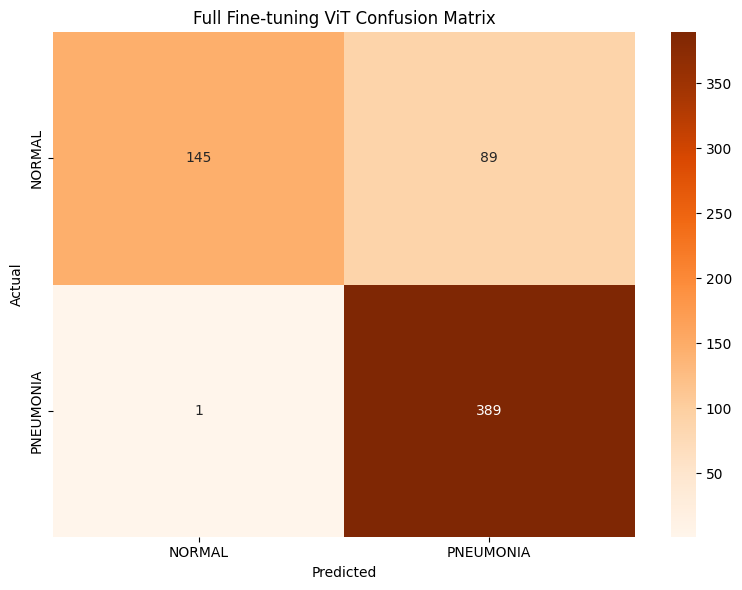

In [9]:
# ================================================
# Evaluate Full ViT on Test Set
# ================================================

model_full.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(device)
        outputs = model_full(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print("=" * 50)
print("FULL Fine-tuning ViT - Test Set Results")
print("=" * 50)
print(classification_report(all_labels, all_preds,
      target_names=["NORMAL", "PNEUMONIA"]))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["NORMAL", "PNEUMONIA"],
            yticklabels=["NORMAL", "PNEUMONIA"])
plt.title("Full Fine-tuning ViT Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

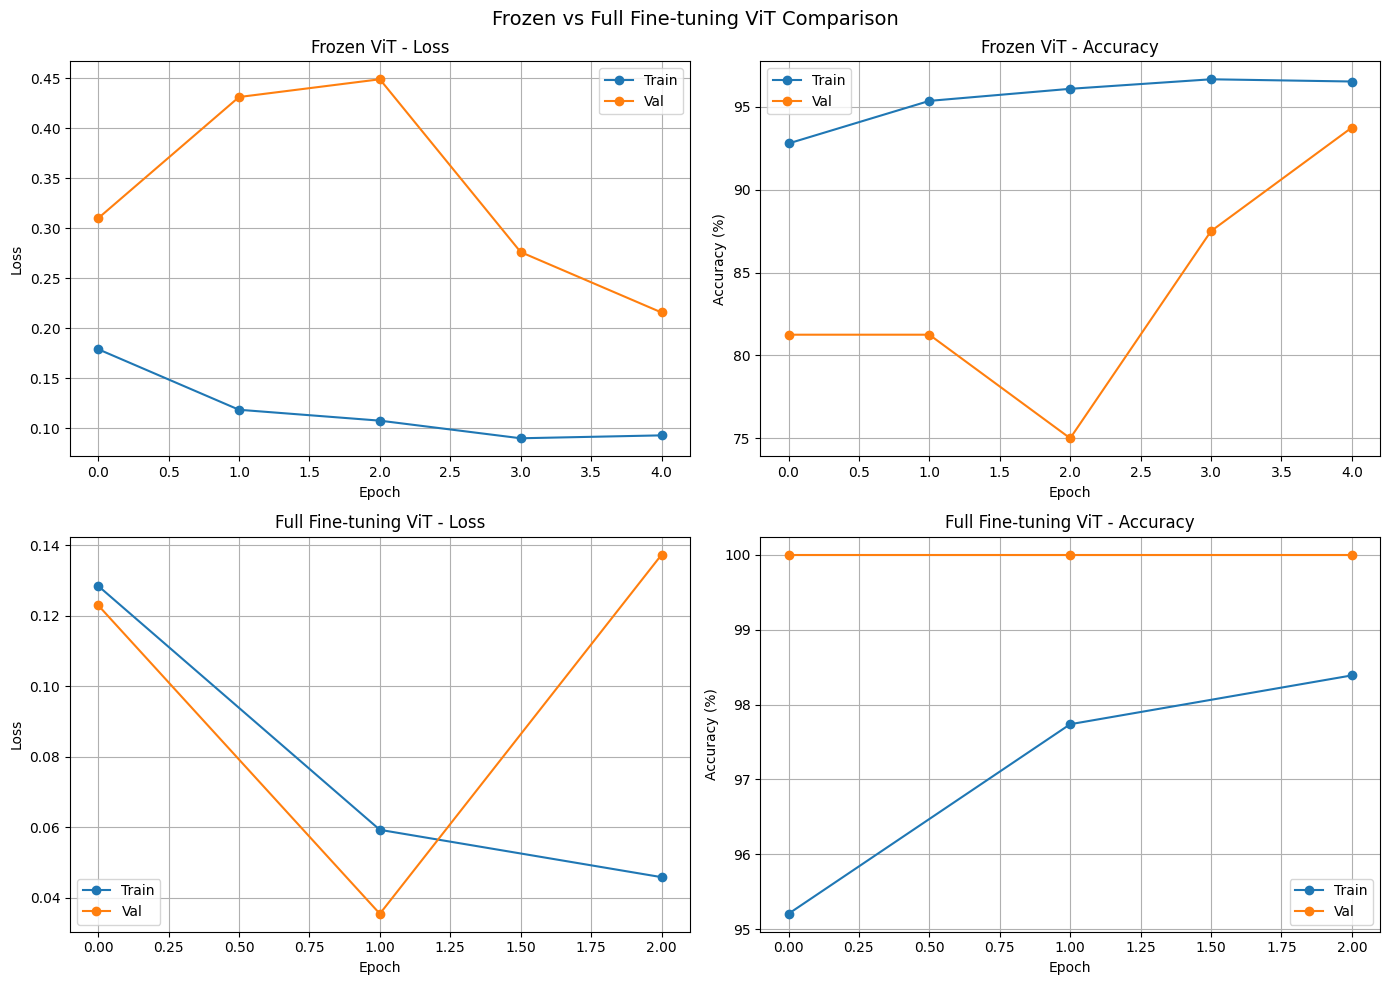

In [10]:
# ================================================
# Compare Frozen vs Full ViT Training Curves
# ================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Frozen - Loss
axes[0,0].plot(train_losses_frozen, label="Train", marker="o")
axes[0,0].plot(val_losses_frozen,   label="Val",   marker="o")
axes[0,0].set_title("Frozen ViT - Loss")
axes[0,0].set_xlabel("Epoch")
axes[0,0].set_ylabel("Loss")
axes[0,0].legend()
axes[0,0].grid(True)

# Frozen - Accuracy
axes[0,1].plot(train_accs_frozen, label="Train", marker="o")
axes[0,1].plot(val_accs_frozen,   label="Val",   marker="o")
axes[0,1].set_title("Frozen ViT - Accuracy")
axes[0,1].set_xlabel("Epoch")
axes[0,1].set_ylabel("Accuracy (%)")
axes[0,1].legend()
axes[0,1].grid(True)

# Full - Loss
axes[1,0].plot(train_losses_full, label="Train", marker="o")
axes[1,0].plot(val_losses_full,   label="Val",   marker="o")
axes[1,0].set_title("Full Fine-tuning ViT - Loss")
axes[1,0].set_xlabel("Epoch")
axes[1,0].set_ylabel("Loss")
axes[1,0].legend()
axes[1,0].grid(True)

# Full - Accuracy
axes[1,1].plot(train_accs_full, label="Train", marker="o")
axes[1,1].plot(val_accs_full,   label="Val",   marker="o")
axes[1,1].set_title("Full Fine-tuning ViT - Accuracy")
axes[1,1].set_xlabel("Epoch")
axes[1,1].set_ylabel("Accuracy (%)")
axes[1,1].legend()
axes[1,1].grid(True)

plt.suptitle("Frozen vs Full Fine-tuning ViT Comparison", fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
# ================================================
# Save Models
# ================================================

import os
os.makedirs("../outputs", exist_ok=True)

torch.save(model_frozen.state_dict(), "../outputs/vit_frozen.pth")
torch.save(model_full.state_dict(),   "../outputs/vit_full.pth")
print("Both ViT models saved!")

Both ViT models saved!
